In [1]:

import seisbench.models as sbm
# list pretrained
names = sbm.PhaseNet.list_pretrained()
print('list_pretrained:', names)
# try loading one and inspect attributes
m = sbm.PhaseNet.from_pretrained(names[0] if names else 'stead')
attrs = [a for a in dir(m) if not a.startswith('_')]
for a in ['docstring', 'name', 'weights_docstring', 'version', 'model_args', 'default_args']:
    if hasattr(m, a):
        print(a, ':', getattr(m, a))
# common seisbench pattern
for a in ['weights_version', 'train_dataset', 'training_dataset']:
    if hasattr(m, a):
        print(a, getattr(m, a))


list_pretrained: ['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']
name : PhaseNet
weights_docstring : Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If you use this model, please reference: Zhu J, Li ZF and Fang LH (2023). USTC-Pickers: a Unified Set of seismic phase pickers Transfer learned for China. Earthq Sci 36(2): 95–112, doi: 10.1016/j.eqs.2023.03.001
default_args : {'P_threshold': 0.3, 'S_threshold': 0.3, 'blinding': [250, 250]}
weights_version 2


#### Preparing high quality training dataset for retraining PhaseNet from scratch on the PNW earthquakes, explosions and surface events

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
#data files
file_noise="/data/whd02/niyiyu_data/PNWML/noise/waveforms.hdf5";
file_comcat=  "/data/whd02/niyiyu_data/PNWML/comcat/waveforms.hdf5";
file_exotic="/data/whd02/niyiyu_data/PNWML/exotic/waveforms.hdf5";

# metadata
# accessing the comcat metadata
comcat_metadata = pd.read_csv("/data/whd02/niyiyu_data/PNWML/comcat/metadata.csv")
# comcat_metadata = pd.read_csv("/data/whd01/yiyu_data/PNWML/comcat_metadata.csv")

# accessing the exotic metadata
exotic_metadata = pd.read_csv("/data/whd02/niyiyu_data/PNWML/exotic/metadata.csv")
# exotic_metadata = pd.read_csv("/data/whd01/yiyu_data/PNWML/exotic_metadata.csv")

# accessing the data files
metadata_noise = pd.read_csv("/data/whd02/niyiyu_data/PNWML/noise/metadata.csv")
# metadata_noise = pd.read_csv("/data/whd01/yiyu_data/PNWML/noise_metadata.csv")

# creating individual data frames for each class

cat_exp = comcat_metadata[comcat_metadata['source_type'] == 'explosion']
cat_eq = comcat_metadata[comcat_metadata['source_type'] == 'earthquake']
cat_su = exotic_metadata[exotic_metadata['source_type'] == 'surface event']
cat_noise = metadata_noise
cat_noise['event_id'] = [cat_noise['trace_start_time'][i]+'_noise' for i in range(len(cat_noise))]

In [4]:
print("Columns in cat_eq:")
print(cat_eq.columns.tolist())

Columns in cat_eq:
['event_id', 'source_origin_time', 'source_latitude_deg', 'source_longitude_deg', 'source_type', 'source_depth_km', 'preferred_source_magnitude', 'preferred_source_magnitude_type', 'preferred_source_magnitude_uncertainty', 'source_depth_uncertainty_km', 'source_horizontal_uncertainty_km', 'station_network_code', 'station_channel_code', 'station_code', 'station_location_code', 'station_latitude_deg', 'station_longitude_deg', 'station_elevation_m', 'trace_name', 'trace_sampling_rate_hz', 'trace_start_time', 'trace_S_arrival_sample', 'trace_P_arrival_sample', 'trace_S_arrival_uncertainty_s', 'trace_P_arrival_uncertainty_s', 'trace_P_polarity', 'trace_S_onset', 'trace_P_onset', 'trace_snr_db', 'source_type_pnsn_label', 'source_local_magnitude', 'source_local_magnitude_uncertainty', 'source_duration_magnitude', 'source_duration_magnitude_uncertainty', 'source_hand_magnitude', 'trace_missing_channel', 'trace_has_offset']


# 1. Seismological Fundamentals First
# P-S Time (source-receiver distance proxy)

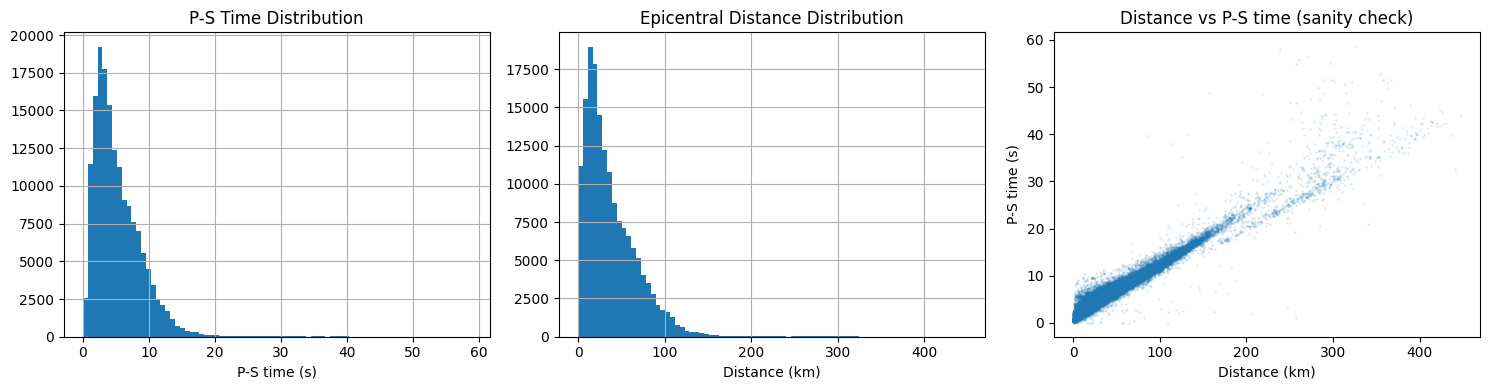

In [5]:
import seisbench.data as sbd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy.geodetics import degrees2kilometers

# Load the dataset
pnw = file_comcat
meta = cat_eq.copy()

# Compute P-S time in seconds (at 100 Hz)
meta['ps_time_s'] = (meta['trace_S_arrival_sample'] - meta['trace_P_arrival_sample']) / 100.0

# Compute epicentral distance
from obspy.geodetics.base import gps2dist_azimuth
meta['epi_dist_km'] = meta.apply(
    lambda r: gps2dist_azimuth(
        r['source_latitude_deg'], r['source_longitude_deg'],
        r['station_latitude_deg'], r['station_longitude_deg']
    )[0] / 1000.0, axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
meta['ps_time_s'].hist(bins=80, ax=axes[0])
axes[0].set_xlabel('P-S time (s)')
axes[0].set_title('P-S Time Distribution')

meta['epi_dist_km'].hist(bins=80, ax=axes[1])
axes[1].set_xlabel('Distance (km)')
axes[1].set_title('Epicentral Distance Distribution')

axes[2].scatter(meta['epi_dist_km'], meta['ps_time_s'], alpha=0.1, s=1)
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('P-S time (s)')
axes[2].set_title('Distance vs P-S time (sanity check)')
plt.tight_layout()

In [13]:
# ── Theoretical conversion ───────────────────────────────────────────────────
Vp = 6.0   # km/s  — typical PNW crustal P velocity
Vs = 3.5   # km/s  — typical PNW crustal S velocity

slowness_diff = (1/Vs) - (1/Vp)          # s/km
km_per_ps_sec = 1.0 / slowness_diff       # km per second of P-S time

print("=== Wadati relationship ===")
print(f"  (1/Vs) - (1/Vp) = (1/{Vs}) - (1/{Vp})")
print(f"                   = {1/Vs:.4f} - {1/Vp:.4f}")
print(f"                   = {slowness_diff:.4f} s/km")
print(f"  → 1 s of P-S time ≈ {km_per_ps_sec:.1f} km")
print()

# ── Verify against your data ─────────────────────────────────────────────────
# The empirical slope from your scatter plot should be close to km_per_ps_sec
from scipy import stats

mask = (
    meta['ps_time_s'].between(0.5, 60) &
    meta['epi_dist_km'].between(1, 450)
)
clean = meta[mask].dropna(subset=['ps_time_s', 'epi_dist_km'])

slope, intercept, r_value, _, std_err = stats.linregress(
    clean['ps_time_s'],
    clean['epi_dist_km']
)

print("=== Empirical fit from your scatter plot ===")
print(f"  slope (empirical) : {slope:.2f} km/s")
print(f"  slope (theory)    : {km_per_ps_sec:.2f} km/s")
print(f"  difference        : {abs(slope - km_per_ps_sec):.2f} km/s  "
      f"({abs(slope - km_per_ps_sec)/km_per_ps_sec*100:.1f}%)")
print(f"  R²                : {r_value**2:.4f}")
print()

# ── Now correctly translate the histogram peak ───────────────────────────────
print("=== P-S time percentiles → distance (corrected) ===")
for q in [0.25, 0.50, 0.75, 0.90]:
    ps_q   = clean['ps_time_s'].quantile(q)
    # Use empirical slope — more honest than assuming a 1D velocity model
    dist_theory   = ps_q / slowness_diff
    dist_empirical = slope * ps_q + intercept
    print(f"  {int(q*100)}th pct: P-S = {ps_q:.1f}s  "
          f"→ theory: {dist_theory:.0f} km  "
          f"| empirical: {dist_empirical:.0f} km")

=== Wadati relationship ===
  (1/Vs) - (1/Vp) = (1/3.5) - (1/6.0)
                   = 0.2857 - 0.1667
                   = 0.1190 s/km
  → 1 s of P-S time ≈ 8.4 km

=== Empirical fit from your scatter plot ===
  slope (empirical) : 8.59 km/s
  slope (theory)    : 8.40 km/s
  difference        : 0.19 km/s  (2.2%)
  R²                : 0.9638

=== P-S time percentiles → distance (corrected) ===
  25th pct: P-S = 2.7s  → theory: 22 km  | empirical: 16 km
  50th pct: P-S = 4.4s  → theory: 37 km  | empirical: 31 km
  75th pct: P-S = 7.2s  → theory: 61 km  | empirical: 55 km
  90th pct: P-S = 10.0s  → theory: 84 km  | empirical: 79 km


## What These Plots Tell You
### Plot 1 — P-S Time Distribution (left)
The distribution is severely right-skewed with a sharp peak at 2–5 seconds and a long tail extending to ~60s. This means:

The vast majority of recordings are very nearby events (local, < 50 km away)
Events beyond ~20s P-S time (> ~150 km) are severely underrepresented
There's a suspicious bimodal-looking bump around 1–3s — this is likely the dominance of very close small-magnitude events that are numerous in the Gutenberg-Richter distribution



Training implication: If you train PhaseNet on this raw distribution, the model will be heavily optimized for short P-S windows. It will likely fail or perform poorly on events at regional distances (> 100 km) because it has rarely seen those waveform patterns.



### Plot 2 — Epicentral Distance Distribution (middle)
Mirrors Plot 1 directly (as expected from the sanity check). The peak is at < 30 km with very few events beyond 200 km. This confirms:

The PNW network is dense and local — it records mostly nearby small earthquakes very well
The distribution is a classic network coverage artifact: stations are clustered in populated areas of Washington/Oregon, so most recorded events are close
There's essentially no data beyond 400 km


### Plot 3 — Distance vs P-S Time Scatter (right)
This is the most physically informative. The tight linear relationship is exactly what you expect from P-S time ≈ distance / Vp_eff (a simple velocity model). The scatter around the line is physical — it reflects:

Real crustal velocity variations across the PNW (Cascadia subduction zone, volcanic arc, back-arc)
Different source depths (deeper events have longer paths)
Some scatter from pick uncertainty

The relationship looks clean and physically consistent — no major outliers cloud of bad picks at implausible values, which is a good data quality indicator. The slight fan-shape widening at larger distances is also physically expected (more path variability).


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Step 1: Make sure ps_time_s exists ──────────────────────────────────────
# This depends on trace_P_arrival_sample and trace_S_arrival_sample
# being numeric — coerce them first

meta['trace_P_arrival_sample'] = pd.to_numeric(
    meta['trace_P_arrival_sample'], errors='coerce'
)
meta['trace_S_arrival_sample'] = pd.to_numeric(
    meta['trace_S_arrival_sample'], errors='coerce'
)

# Compute P-S time in seconds (sampling rate = 100 Hz)
meta['ps_time_s'] = (
    meta['trace_S_arrival_sample'] - meta['trace_P_arrival_sample']
) / 100.0

# Sanity check before proceeding
n_missing = meta['ps_time_s'].isna().sum()
n_negative = (meta['ps_time_s'] < 0).sum()
print(f"ps_time_s computed: {len(meta):,} traces")
print(f"  NaN (missing P or S pick) : {n_missing:,}")
print(f"  Negative (S before P)     : {n_negative:,}  ← physical impossibility, will be dropped")
print(f"  Valid                     : {(meta['ps_time_s'] > 0).sum():,}")
print()

# Drop rows where ps_time_s is invalid
meta = meta[meta['ps_time_s'] > 0].copy()

# ── Step 2: Create ps_bin ────────────────────────────────────────────────────
bins   = [0, 2, 5, 10, 20, 40, 65]
labels = [
    '<2s (very local)',
    '2-5s (local)',
    '5-10s (near-regional)',
    '10-20s (regional)',
    '20-40s (far-regional)',
    '>40s (teleseismic fringe)'
]

meta['ps_bin'] = pd.cut(
    meta['ps_time_s'],
    bins   = bins,
    labels = labels
)

# Confirm it was created
print(f"ps_bin column created: {meta['ps_bin'].notna().sum():,} labelled traces")
print(f"ps_bin NaN (outside bin range): {meta['ps_bin'].isna().sum():,}")
print()

# ── Step 3: Now safely compute bin counts ───────────────────────────────────
bin_counts = meta['ps_bin'].value_counts().sort_index()

print("=== Dataset inventory ===")
print(f"Total traces: {len(meta):,}")
print()
for bin_label, count in bin_counts.items():
    pct = count / len(meta) * 100
    bar = '█' * int(pct / 2)
    print(f"  {str(bin_label):<35} : {count:>6,}  ({pct:4.1f}%)  {bar}")

print()
print(f"Imbalance ratio: {bin_counts.max()/bin_counts.min():.0f}x")

ps_time_s computed: 163,064 traces
  NaN (missing P or S pick) : 0
  Negative (S before P)     : 0  ← physical impossibility, will be dropped
  Valid                     : 163,064

ps_bin column created: 163,064 labelled traces
ps_bin NaN (outside bin range): 0

=== Dataset inventory ===
Total traces: 163,064

  <2s (very local)                    : 25,295  (15.5%)  ███████
  2-5s (local)                        : 67,037  (41.1%)  ████████████████████
  5-10s (near-regional)               : 54,459  (33.4%)  ████████████████
  10-20s (regional)                   : 15,170  ( 9.3%)  ████
  20-40s (far-regional)               :  1,007  ( 0.6%)  
  >40s (teleseismic fringe)           :     96  ( 0.1%)  

Imbalance ratio: 698x


## 2. Magnitude Distribution

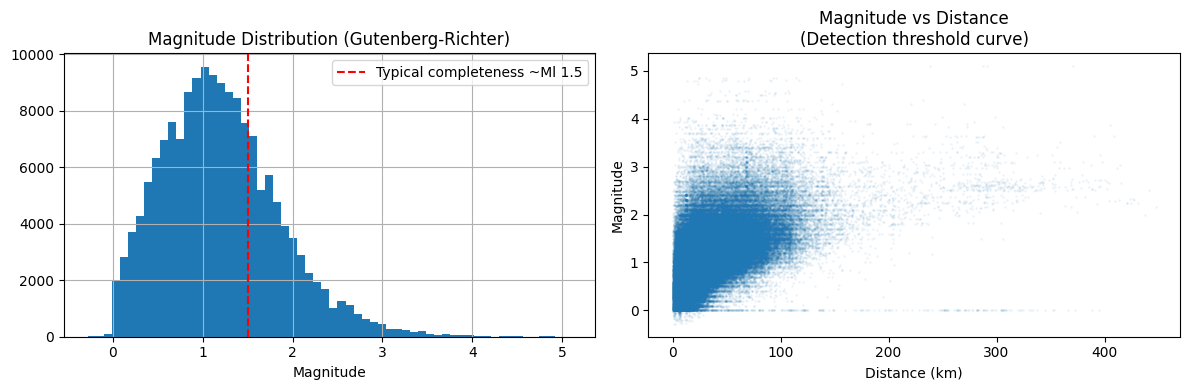

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
meta['preferred_source_magnitude'].hist(bins=60, ax=axes[0])
axes[0].set_xlabel('Magnitude')
axes[0].set_title('Magnitude Distribution (Gutenberg-Richter)')
axes[0].axvline(1.5, color='r', linestyle='--', label='Typical completeness ~Ml 1.5')
axes[0].legend()

# 2D: magnitude vs distance — critical for understanding SNR coverage
axes[1].scatter(meta['epi_dist_km'], meta['preferred_source_magnitude'],
                alpha=0.05, s=1)
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Magnitude')
axes[1].set_title('Magnitude vs Distance\n(Detection threshold curve)')
plt.tight_layout()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def parse_snr(snr_str):
    """
    Parse 'snr(E)|snr(N)|snr(Z)' string into individual components.
    Returns dict with E, N, Z SNR values and their mean.
    Handles NaN, malformed strings, and missing channels gracefully.
    """
    if pd.isna(snr_str) or snr_str == '':
        return {'snr_E': np.nan, 'snr_N': np.nan, 'snr_Z': np.nan, 'snr_mean': np.nan, 'snr_Z_only': np.nan}
    
    try:
        parts = str(snr_str).split('|')
        vals = [float(p) if p not in ('', 'nan', 'None') else np.nan for p in parts]
        
        # Pad to 3 if missing channels
        while len(vals) < 3:
            vals.append(np.nan)
        
        snr_E, snr_N, snr_Z = vals[0], vals[1], vals[2]
        snr_mean = np.nanmean([snr_E, snr_N, snr_Z])
        
        return {
            'snr_E': snr_E,
            'snr_N': snr_N,
            'snr_Z': snr_Z,
            'snr_mean': snr_mean,
            'snr_Z_only': snr_Z   # Z is most critical for P picking
        }
    except Exception:
        return {'snr_E': np.nan, 'snr_N': np.nan, 'snr_Z': np.nan, 'snr_mean': np.nan, 'snr_Z_only': np.nan}

# Parse and expand into new columns
snr_parsed = meta['trace_snr_db'].apply(parse_snr).apply(pd.Series)
meta = pd.concat([meta, snr_parsed], axis=1)

# Quick sanity check
print(meta[['trace_snr_db', 'snr_E', 'snr_N', 'snr_Z', 'snr_mean']].head(10))
print(f"\nNaN rate per channel:")
for col in ['snr_E', 'snr_N', 'snr_Z']:
    print(f"  {col}: {meta[col].isna().mean():.1%}")

          trace_snr_db   snr_E   snr_N   snr_Z   snr_mean
0   6.135|3.065|11.766   6.135   3.065  11.766   6.988667
1       nan|nan|22.583     NaN     NaN  22.583  22.583000
2    1.756|3.057|3.551   1.756   3.057   3.551   2.788000
3       nan|nan|27.185     NaN     NaN  27.185  27.185000
4  10.881|17.107|2.242  10.881  17.107   2.242  10.076667
5  29.412|30.57|29.827  29.412  30.570  29.827  29.936333
6  14.863|14.12|21.324  14.863  14.120  21.324  16.769000
7    1.175|3.011|5.552   1.175   3.011   5.552   3.246000
8       nan|nan|34.579     NaN     NaN  34.579  34.579000
9       nan|nan|36.606     NaN     NaN  36.606  36.606000

NaN rate per channel:
  snr_E: 28.4%
  snr_N: 28.4%
  snr_Z: 2.0%


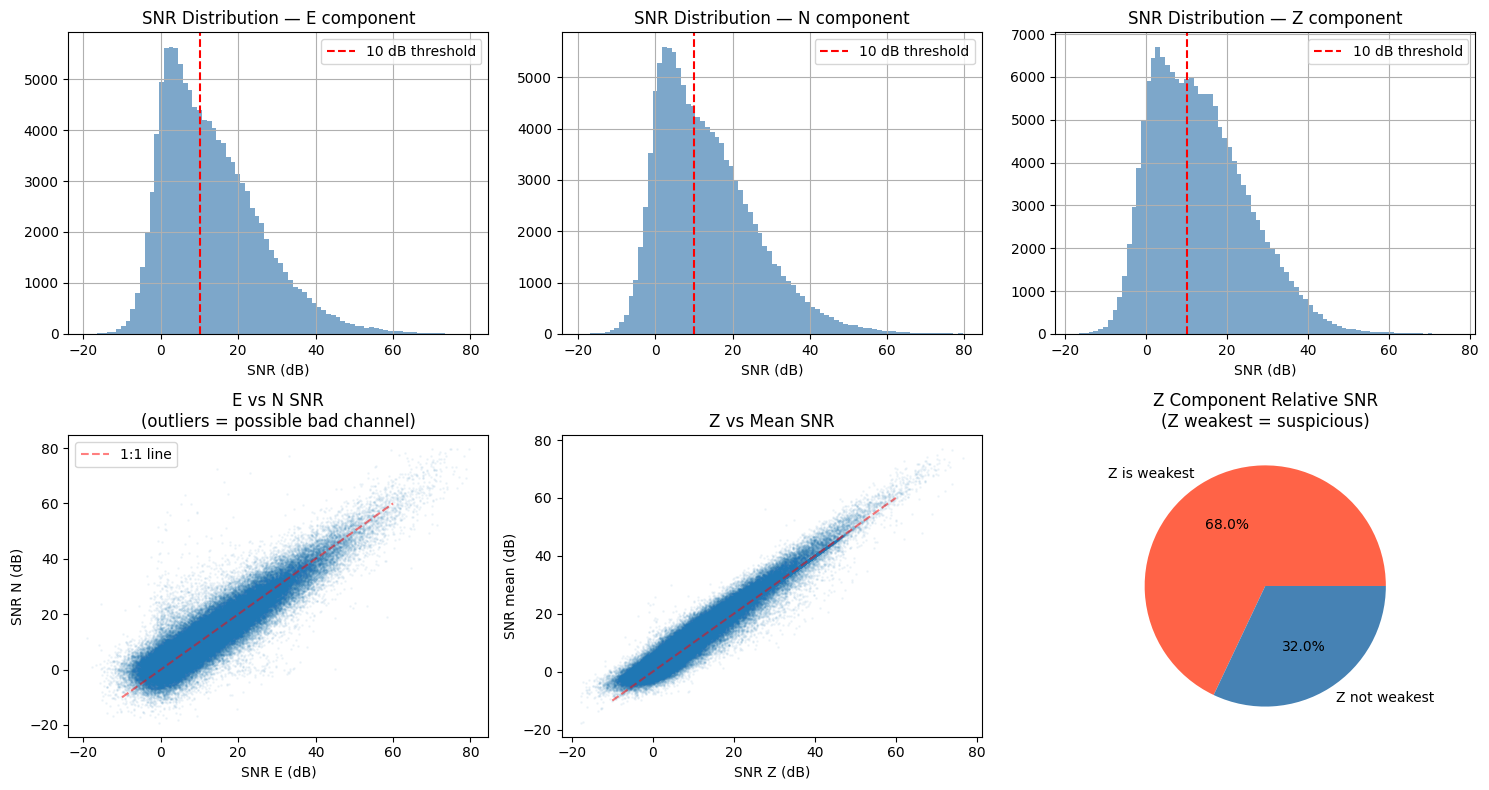

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# --- Row 1: Per-component SNR distributions ---
for ax, col, label in zip(axes[0], ['snr_E', 'snr_N', 'snr_Z'], ['E', 'N', 'Z']):
    meta[col].hist(bins=80, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(10, color='r', linestyle='--', label='10 dB threshold')
    ax.set_xlabel('SNR (dB)')
    ax.set_title(f'SNR Distribution — {label} component')
    ax.legend()

# --- Row 2: Cross-component analysis ---

# E vs N SNR — should be correlated (horizontal noise), outliers = bad channels
axes[1, 0].scatter(meta['snr_E'], meta['snr_N'], alpha=0.05, s=1)
axes[1, 0].set_xlabel('SNR E (dB)')
axes[1, 0].set_ylabel('SNR N (dB)')
axes[1, 0].set_title('E vs N SNR\n(outliers = possible bad channel)')
axes[1, 0].plot([-10, 60], [-10, 60], 'r--', alpha=0.5, label='1:1 line')
axes[1, 0].legend()

# Z vs mean SNR — Z is most critical for P, horizontals for S
axes[1, 1].scatter(meta['snr_Z'], meta['snr_mean'], alpha=0.05, s=1)
axes[1, 1].set_xlabel('SNR Z (dB)')
axes[1, 1].set_ylabel('SNR mean (dB)')
axes[1, 1].set_title('Z vs Mean SNR')
axes[1, 1].plot([-10, 60], [-10, 60], 'r--', alpha=0.5)

# How often is Z the weakest channel? (anomaly flag)
meta['z_is_weakest'] = meta[['snr_E','snr_N','snr_Z']].apply(
    lambda r: r['snr_Z'] == r[['snr_E','snr_N','snr_Z']].min(), axis=1
)
axes[1, 2].pie(
    [meta['z_is_weakest'].sum(), (~meta['z_is_weakest']).sum()],
    labels=['Z is weakest', 'Z not weakest'],
    autopct='%1.1f%%',
    colors=['tomato', 'steelblue']
)
axes[1, 2].set_title('Z Component Relative SNR\n(Z weakest = suspicious)')

plt.tight_layout()

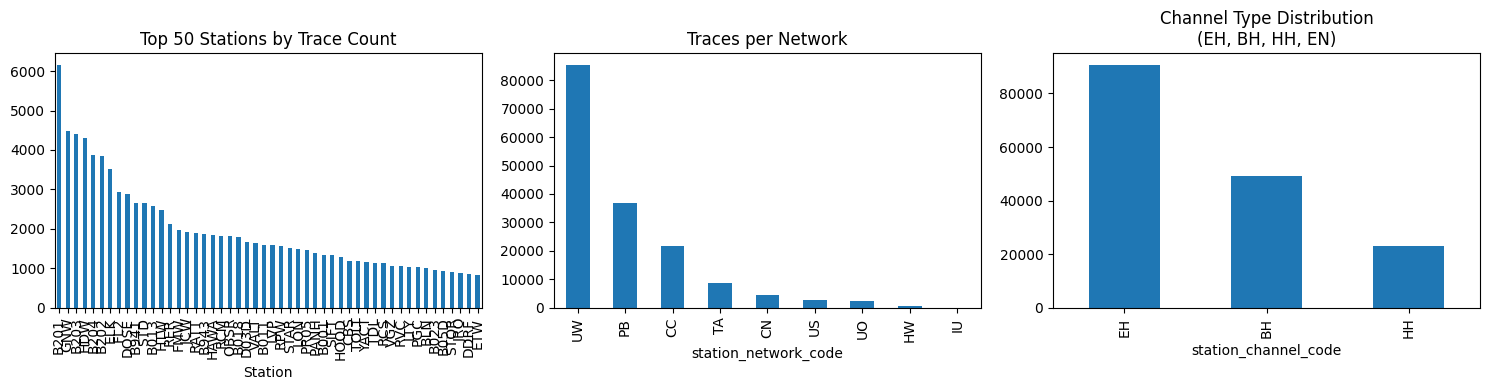

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Traces per station — are a few stations dominating?
station_counts = meta.groupby('station_code').size().sort_values(ascending=False)
station_counts.head(50).plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 50 Stations by Trace Count')
axes[0].set_xlabel('Station')

# Traces per network
meta['station_network_code'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Traces per Network')

# Channel type distribution
meta['station_channel_code'].str[:2].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Channel Type Distribution\n(EH, BH, HH, EN)')
plt.tight_layout()

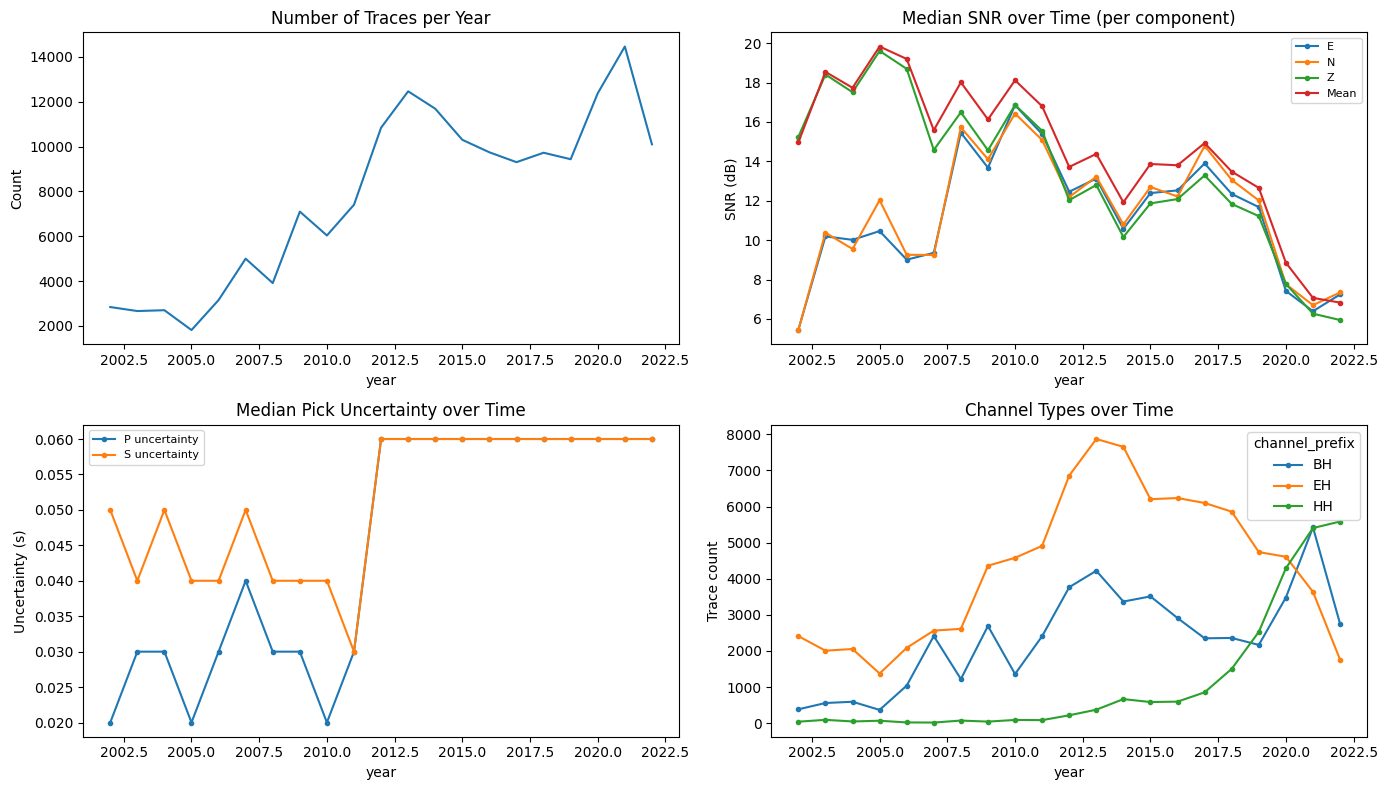

In [10]:
meta['source_origin_time'] = pd.to_datetime(meta['source_origin_time'])
meta['year'] = meta['source_origin_time'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Event count over time ────────────────────────────────────────────────────
meta.groupby('year').size().plot(ax=axes[0, 0])
axes[0, 0].set_title('Number of Traces per Year')
axes[0, 0].set_ylabel('Count')

# ── Median SNR over time — now using numeric snr_mean ───────────────────────
# Plot all three components + mean so you can see if one channel degrades
snr_by_year = meta.groupby('year')[['snr_E', 'snr_N', 'snr_Z', 'snr_mean']].median()
snr_by_year.plot(ax=axes[0, 1], marker='o', markersize=3)
axes[0, 1].set_title('Median SNR over Time (per component)')
axes[0, 1].set_ylabel('SNR (dB)')
axes[0, 1].legend(['E', 'N', 'Z', 'Mean'], fontsize=8)

# ── Median P pick uncertainty over time ─────────────────────────────────────
# trace_P_arrival_uncertainty_s might also have non-numeric entries — coerce safely
meta['trace_P_arrival_uncertainty_s'] = pd.to_numeric(
    meta['trace_P_arrival_uncertainty_s'], errors='coerce'
)
meta['trace_S_arrival_uncertainty_s'] = pd.to_numeric(
    meta['trace_S_arrival_uncertainty_s'], errors='coerce'
)

unc_by_year = meta.groupby('year')[
    ['trace_P_arrival_uncertainty_s', 'trace_S_arrival_uncertainty_s']
].median()
unc_by_year.plot(ax=axes[1, 0], marker='o', markersize=3)
axes[1, 0].set_title('Median Pick Uncertainty over Time')
axes[1, 0].set_ylabel('Uncertainty (s)')
axes[1, 0].legend(['P uncertainty', 'S uncertainty'], fontsize=8)

# ── Channel type evolution ───────────────────────────────────────────────────
meta['channel_prefix'] = meta['station_channel_code'].str[:2]
meta.groupby(['year', 'channel_prefix']) \
    .size() \
    .unstack(fill_value=0) \
    .plot(ax=axes[1, 1], marker='o', markersize=3)
axes[1, 1].set_title('Channel Types over Time')
axes[1, 1].set_ylabel('Trace count')

plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=150)
plt.show()

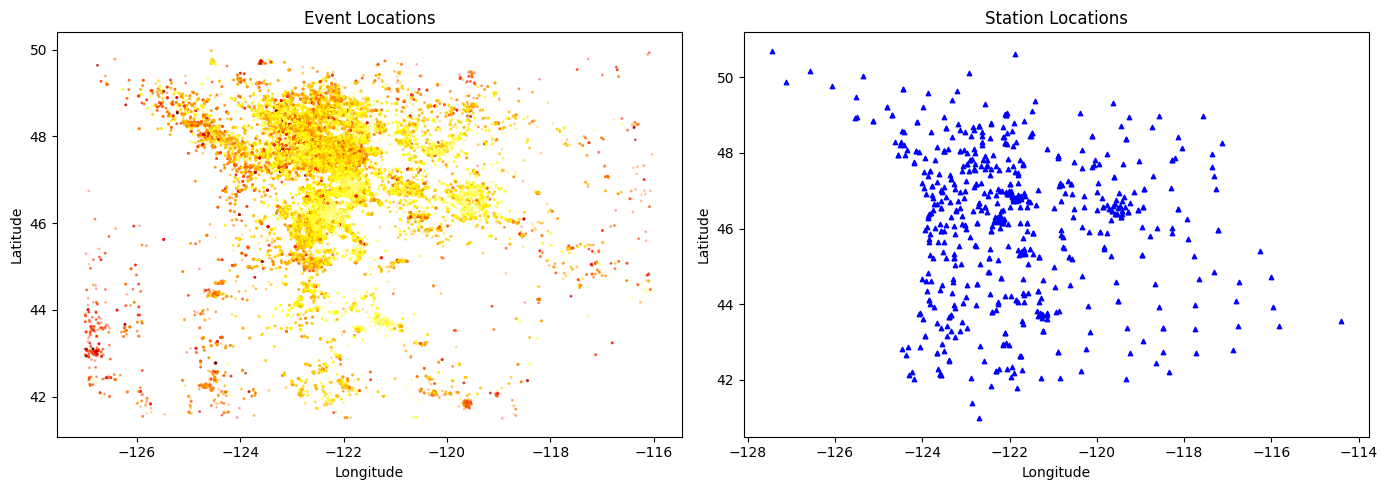

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Event locations
axes[0].scatter(meta['source_longitude_deg'], meta['source_latitude_deg'],
                s=1, alpha=0.3, c=meta['preferred_source_magnitude'], cmap='hot_r')
axes[0].set_title('Event Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Station locations
stations = meta.groupby('station_code').first()
axes[1].scatter(stations['station_longitude_deg'], stations['station_latitude_deg'],
                s=10, marker='^', color='blue')
axes[1].set_title('Station Locations')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.tight_layout()

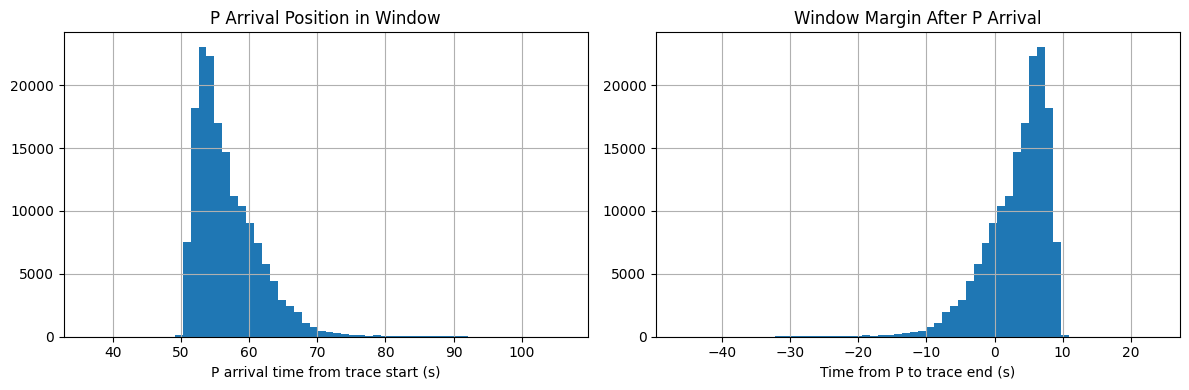

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Where does P fall in the 60-second trace?
meta['p_position_s'] = meta['trace_P_arrival_sample'] / 100.0
meta['s_position_s'] = meta['trace_S_arrival_sample'] / 100.0

meta['p_position_s'].hist(bins=60, ax=axes[0])
axes[0].set_xlabel('P arrival time from trace start (s)')
axes[0].set_title('P Arrival Position in Window')

# P-to-window-end margin
meta['p_to_end_s'] = 60.0 - meta['p_position_s']
meta['p_to_end_s'].hist(bins=60, ax=axes[1])
axes[1].set_xlabel('Time from P to trace end (s)')
axes[1].set_title('Window Margin After P Arrival')
plt.tight_layout()

### Metadata distributions for `cat_eq`

Exploratory histograms (and summary statistics) for earthquake rows in the comcat metadata: **depth**, **magnitude**, **S−P lag** (`trace_S_arrival_sample` − `trace_P_arrival_sample`), **snr_z**, and **snr_min** (minimum of E/N/Z components parsed from `trace_snr_db`).

In [ ]:
# --- Full metadata distributions for cat_eq (earthquake rows only) ---
meta = cat_eq.copy()

# --- Resolve column names (metadata CSV naming can vary slightly) ---
def pick_col(df, substr):
    for c in df.columns:
        if substr.lower() in c.lower():
            return c
    return None

if "source_depth_km" in meta.columns:
    depth_col = "source_depth_km"
else:
    depth_col = pick_col(meta, "depth_km") or pick_col(meta, "depth")

mag_col = pick_col(meta, "magnitude")  # e.g. source_magnitude
p_col = pick_col(meta, "trace_p_arrival_sample") or pick_col(meta, "trace_P_arrival_sample")
s_col = pick_col(meta, "trace_s_arrival_sample") or pick_col(meta, "trace_S_arrival_sample")

# Parse SNR from pipe-separated trace_snr_db: E|N|Z
if "trace_snr_db" in meta.columns:
    snr_split = meta["trace_snr_db"].astype(str).str.split("|", expand=True)
    meta["snr_E"] = pd.to_numeric(snr_split[0], errors="coerce")
    meta["snr_N"] = pd.to_numeric(snr_split[1], errors="coerce")
    meta["snr_z"] = pd.to_numeric(snr_split[2], errors="coerce")
    meta["snr_min"] = meta[["snr_E", "snr_N", "snr_z"]].min(axis=1)
else:
    meta["snr_z"] = np.nan
    meta["snr_min"] = np.nan

# S − P lag in samples (requires both picks)
if p_col and s_col:
    meta["sp_lag_samples"] = pd.to_numeric(meta[s_col], errors="coerce") - pd.to_numeric(meta[p_col], errors="coerce")
else:
    meta["sp_lag_samples"] = np.nan

# --- Build series for plotting (drop NaN per panel) ---
panels = []

if depth_col and depth_col in meta.columns:
    panels.append(("Depth (km)", meta[depth_col], {"xmin": 0}))
else:
    print("Warning: depth column not found")

if mag_col:
    panels.append((f"Magnitude ({mag_col})", meta[mag_col], {}))
else:
    print("Warning: no column containing 'magnitude' found")

if meta["sp_lag_samples"].notna().any():
    panels.append(("S−P lag (samples)", meta["sp_lag_samples"], {"xmin": 0}))

if meta["snr_z"].notna().any():
    panels.append(("snr_z (dB)", meta["snr_z"], {}))

if meta["snr_min"].notna().any():
    panels.append(("snr_min (dB)", meta["snr_min"], {}))

n = len(panels)
if n == 0:
    raise RuntimeError("No plottable columns computed — check cat_eq columns.")

ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "coral", "teal"]
for ax, (title, series, kw), color in zip(axes, panels, colors):
    s = pd.to_numeric(series, errors="coerce").dropna()
    ax.hist(s, bins=80, color=color, edgecolor="white", linewidth=0.3, alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel("Count")
    if "xmin" in kw:
        ax.set_xlim(left=kw["xmin"])
    ax.grid(True, alpha=0.3)
    m = s.median()
    ax.axvline(m, color="black", ls="--", lw=1, alpha=0.7)
    ax.text(0.98, 0.95, f"n={len(s):,}\nmedian={m:.3g}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, family="monospace",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

for j in range(len(panels), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("cat_eq metadata distributions", y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

print("Column mapping:")
print(f"  depth: {depth_col!r}" if depth_col and depth_col in meta.columns else "  depth: MISSING")
print(f"  magnitude: {mag_col!r}" if mag_col else "  magnitude: MISSING")
print(f"  P arrival: {p_col!r}" if p_col else "  P arrival: MISSING")
print(f"  S arrival: {s_col!r}" if s_col else "  S arrival: MISSING")
print()
sum_cols = [c for c in [depth_col, mag_col, "sp_lag_samples", "snr_z", "snr_min"] if c and c in meta.columns]
print(meta[sum_cols].describe().to_string())


### Filter high quality picks

- 'trace_has_offset' is a data quality indicator. It indicates if the waveform has a DC shift. It could mean that the signal is not centered on zero or signal has some shift. 

- 'trace_missing_channel' 

In [45]:
df = cat_eq.copy()


snr_split = df['trace_snr_db'].str.split('|', expand=True)

df['snr_E'] = snr_split[0].astype(float)
df['snr_N'] = snr_split[1].astype(float)
df['snr_Z'] = snr_split[2].astype(float)


df['snr_min'] = df[['snr_E','snr_N','snr_Z']].min(axis=1)

df['snr_mean'] = df[['snr_E','snr_N','snr_Z']].mean(axis=1)

df['snr_Z_only'] = df['snr_Z']



df = df[
    (df.trace_P_arrival_sample.notnull()) &
    (df.trace_S_arrival_sample.notnull()) &
    #(df.snr_Z_only > 10) &  # tune threshold
    (~df.trace_has_offset) &
    (~df.trace_missing_channel)
]

### Plot the SNR distribution of SNR

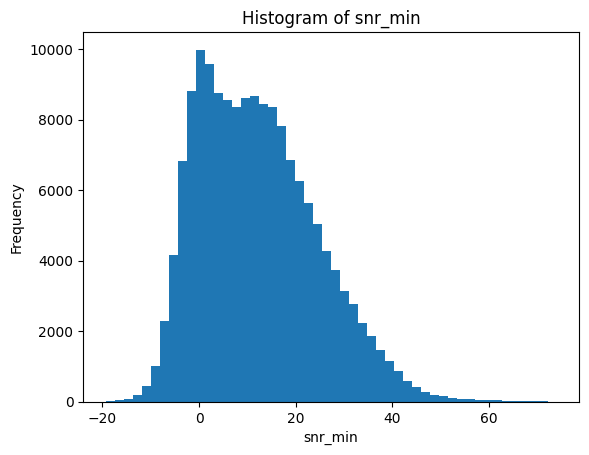

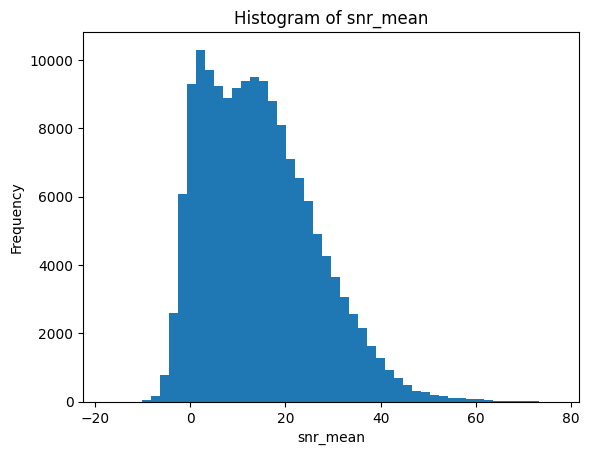

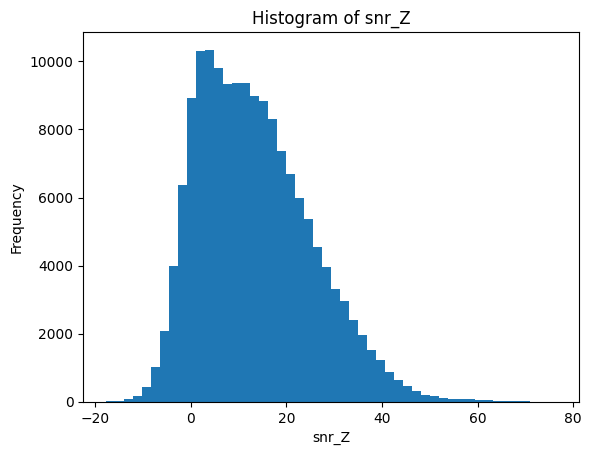

In [46]:
# Plot histograms for snr_min, snr_mean, snr_Z from a DataFrame `df`

# Ensure required columns exist
cols = ['snr_min', 'snr_mean', 'snr_Z']
missing = [c for c in cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in dataframe: {missing}")

# Create separate plots as required
for col in cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Filtering based on SNR

In [47]:
df = df[(df.snr_min > 10)]

### Removing the Station Bias

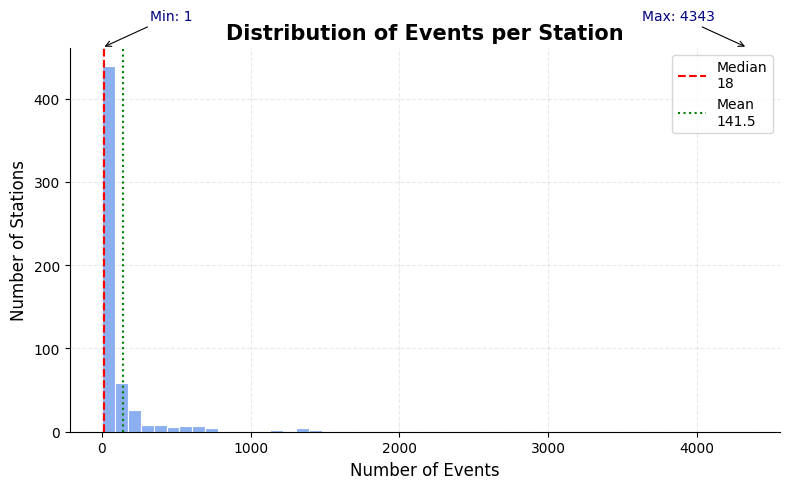

In [ ]:
# Count number of traces/events per station
station_counts = df['station_code'].value_counts()



# Prettified histogram
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(station_counts.values, bins=50, kde=False, color="cornflowerblue", edgecolor="white", ax=ax)

# Show median/mean as vertical lines
median = np.median(station_counts.values)
mean = np.mean(station_counts.values)

ax.axvline(median, color='red', linestyle='dashed', linewidth=1.5, label=f'Median\n{int(median)}')
ax.axvline(mean, color='green', linestyle='dotted', linewidth=1.5, label=f'Mean\n{mean:.1f}')

# Annotate extremes (optional)
max_val = int(station_counts.values.max())
min_val = int(station_counts.values.min())
ax.annotate(f"Max: {max_val}", xy=(max_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(-50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')
ax.annotate(f"Min: {min_val}", xy=(min_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')

ax.set_title("Distribution of Events per Station", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Events", fontsize=12)
ax.set_ylabel("Number of Stations", fontsize=12)
ax.grid(True, alpha=0.28, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

In [53]:
K = 1000
df = df.groupby('station_code', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), K), random_state=42)
)

/tmp/ipykernel_2077080/2459579731.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('station_code', group_keys=False).apply(


### Removing the event bias

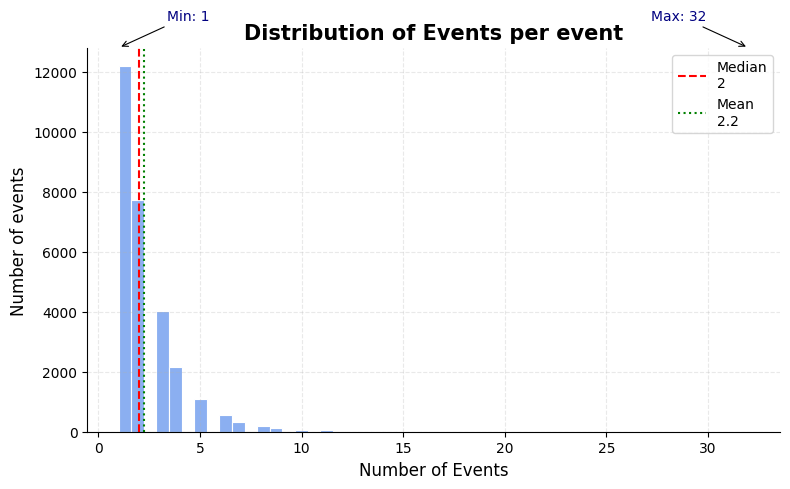

In [55]:
# Count number of traces/events per event
event_counts = df['event_id'].value_counts()



# Prettified histogram
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(event_counts.values, bins=50, kde=False, color="cornflowerblue", edgecolor="white", ax=ax)

# Show median/mean as vertical lines
median = np.median(event_counts.values)
mean = np.mean(event_counts.values)

ax.axvline(median, color='red', linestyle='dashed', linewidth=1.5, label=f'Median\n{int(median)}')
ax.axvline(mean, color='green', linestyle='dotted', linewidth=1.5, label=f'Mean\n{mean:.1f}')

# Annotate extremes (optional)
max_val = int(event_counts.values.max())
min_val = int(event_counts.values.min())
ax.annotate(f"Max: {max_val}", xy=(max_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(-50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')
ax.annotate(f"Min: {min_val}", xy=(min_val, 1), xycoords=('data', 'axes fraction'),
            xytext=(50,20), textcoords='offset points', arrowprops=dict(arrowstyle='->', lw=0.8),
            fontsize=10, ha='center', color='navy')

ax.set_title("Distribution of Events per event", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Events", fontsize=12)
ax.set_ylabel("Number of events", fontsize=12)
ax.grid(True, alpha=0.28, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

In [56]:
K = 5
df = df.groupby('event_id', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), K), random_state=42)
)

/tmp/ipykernel_2077080/3559123978.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('event_id', group_keys=False).apply(
